CNN:
Summary metrics (positive class = unhealthy):
Accuracy:  0.9768
Precision: 0.9665
Recall:    0.9665
F1-score:  0.9665
ROC AUC:   0.9962

Random Forest:
Summary metrics (positive class = unhealthy):
Accuracy:  0.9208
Precision: 0.9313
Recall:    0.8324
F1-score:  0.8791
ROC-AUC:   0.9806

SVM:
Summary metrics (positive class = unhealthy):
Accuracy:  0.9151
Precision: 0.9091
Recall:    0.8380
F1-score:  0.8721
ROC-AUC:   0.9686


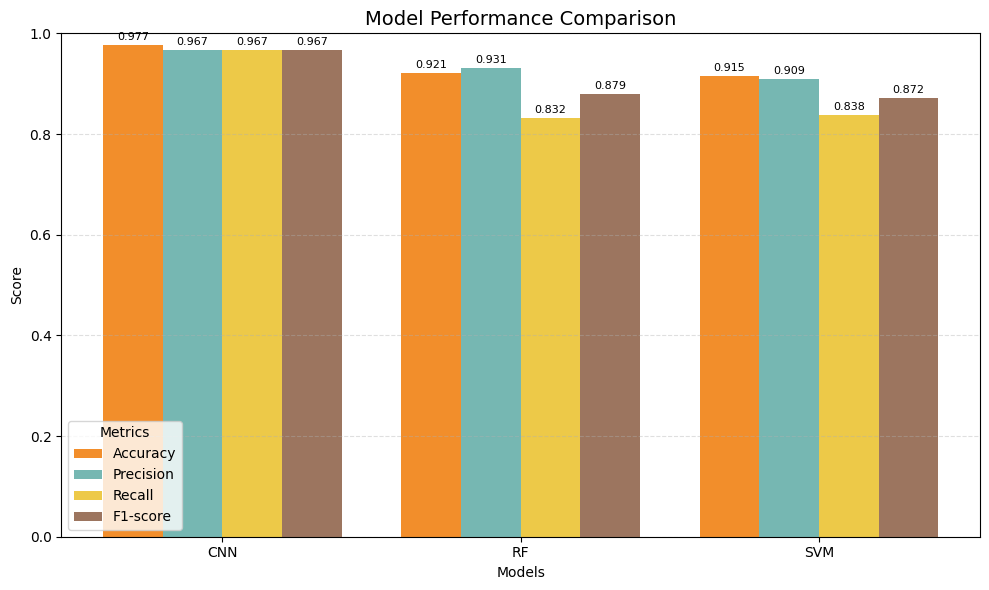

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics excluding ROC-AUC
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
model_names = ["CNN", "RF", "SVM"]
scores = {
    "Accuracy": [0.9768, 0.9208, 0.9151],
    "Precision": [0.9665, 0.9313, 0.9091],
    "Recall": [0.9665, 0.8324, 0.8380],
    "F1-score": [0.9665, 0.8791, 0.8721],
}

# Colorblind-friendly palette avoiding red-green and blue-purple pairs
metric_colors = ["#F28E2B", "#76B7B2", "#EDC948", "#9C755F"]

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + (i - 1.5) * width,
        scores[metric],
        width,
        label=metric,
        color=metric_colors[i],
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

ax.set_title("Model Performance Comparison", fontsize=14)
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.00)
ax.legend(title="Metrics")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


Hybrid (CNN as feature extractor + SVM for prediction):
Summary metrics (positive class = unhealthy):
Accuracy:  0.9749
Precision: 0.9663
Recall:    0.9609
F1-score:  0.9636
ROC-AUC:   0.9916


Hybrid (CNN as feature extractor + SVM for prediction):
Summary metrics (positive class = unhealthy):
Accuracy:  0.9749
Precision: 0.9663
Recall:    0.9609
F1-score:  0.9636
ROC-AUC:   0.9916

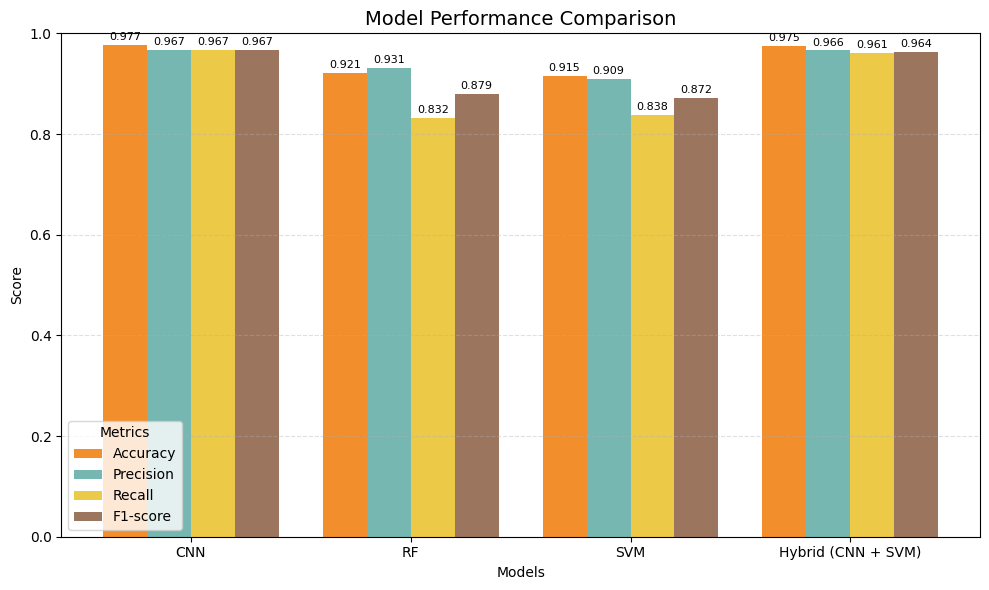

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics excluding ROC-AUC
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
model_names = ["CNN", "RF", "SVM", "Hybrid (CNN + SVM)"]
scores = {
    "Accuracy": [0.9768, 0.9208, 0.9151, 0.9749],
    "Precision": [0.9665, 0.9313, 0.9091, 0.9663],
    "Recall": [0.9665, 0.8324, 0.8380, 0.9609],
    "F1-score": [0.9665, 0.8791, 0.8721, 0.9636],
}

# Colorblind-friendly palette avoiding red-green and blue-purple pairs
metric_colors = ["#F28E2B", "#76B7B2", "#EDC948", "#9C755F"]

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + (i - 1.5) * width,
        scores[metric],
        width,
        label=metric,
        color=metric_colors[i],
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

ax.set_title("Model Performance Comparison", fontsize=14)
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.00)
ax.legend(title="Metrics")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

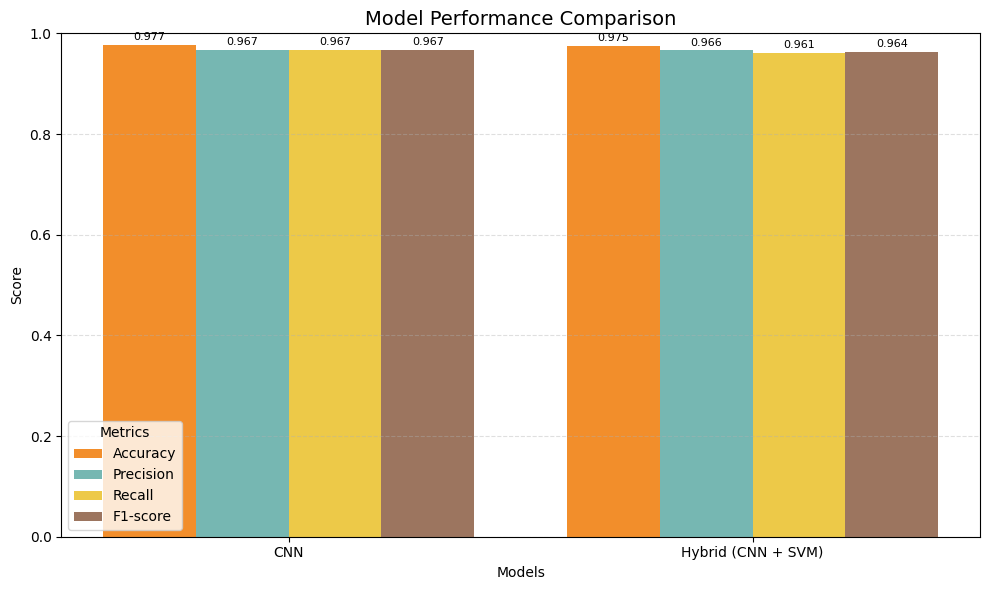

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics excluding ROC-AUC
metrics = ["Accuracy", "Precision", "Recall", "F1-score"]
model_names = ["CNN", "Hybrid (CNN + SVM)"]
scores = {
    "Accuracy": [0.9768, 0.9749],
    "Precision": [0.9665, 0.9663],
    "Recall": [0.9665, 0.9609],
    "F1-score": [0.9665, 0.9636],
}

# Colorblind-friendly palette avoiding red-green and blue-purple pairs
metric_colors = ["#F28E2B", "#76B7B2", "#EDC948", "#9C755F"]

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))

for i, metric in enumerate(metrics):
    bars = ax.bar(
        x + (i - 1.5) * width,
        scores[metric],
        width,
        label=metric,
        color=metric_colors[i],
    )
    ax.bar_label(bars, fmt="%.3f", padding=2, fontsize=8)

ax.set_title("Model Performance Comparison", fontsize=14)
ax.set_xlabel("Models")
ax.set_ylabel("Score")
ax.set_xticks(x)
ax.set_xticklabels(model_names)
ax.set_ylim(0, 1.00)
ax.legend(title="Metrics")
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

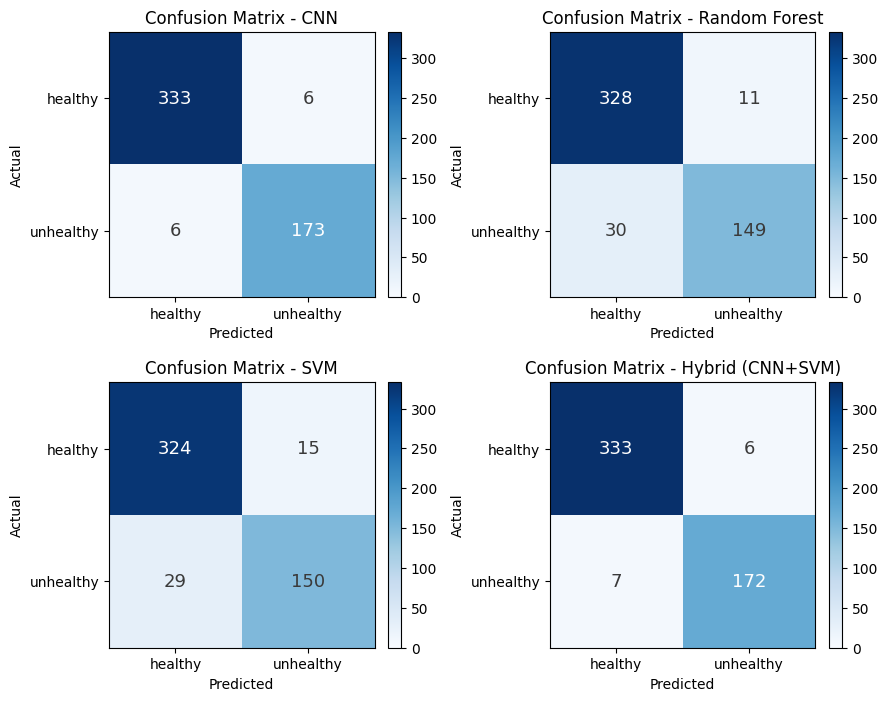

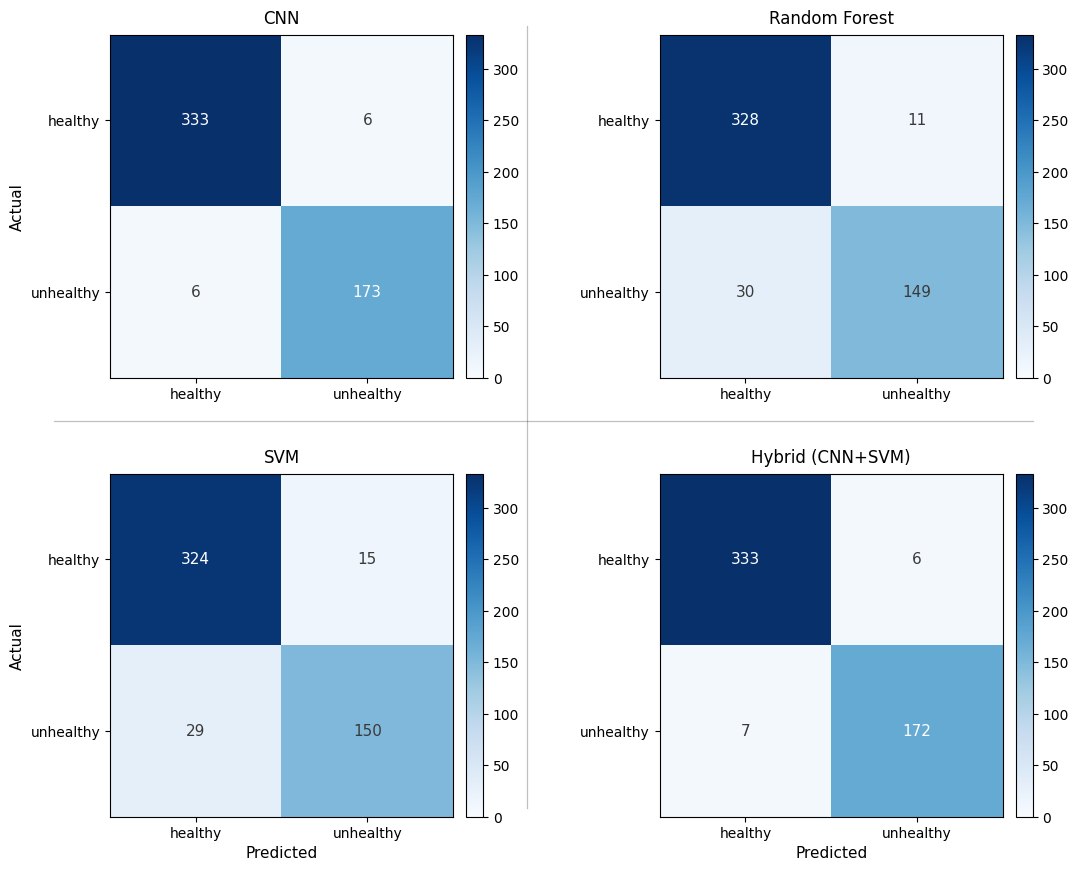

In [19]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# Confusion matrices in the form: [[TN, FP], [FN, TP]]
conf_mats = {
    "CNN": np.array([[333, 6], [6, 173]]),
    "Random Forest": np.array([[328, 11], [30, 149]]),
    "SVM": np.array([[324, 15], [29, 150]]),
    "Hybrid (CNN+SVM)": np.array([[333, 6], [7, 172]]),
}

labels = ["healthy", "unhealthy"]
vmax = max(matrix.max() for matrix in conf_mats.values())

# Create 2x2 canvas
fig, axes = plt.subplots(2, 2, figsize=(11, 9.2))
axes = axes.ravel()

# For each panel: (title, show x label, show y label)
panel_layout = [
    ("CNN", False, True),
    ("Random Forest", False, False),
    ("SVM", True, True),
    ("Hybrid (CNN+SVM)", True, False),
]

def draw_matrix(ax, title, matrix, show_xlabel, show_ylabel):
    """Draw one confusion matrix panel."""
    image = ax.imshow(matrix, cmap="Blues", vmin=0, vmax=vmax)

    # Write values inside cells
    for r in range(2):
        for c in range(2):
            value = matrix[r, c]
            text_color = "white" if value > vmax * 0.5 else "#3a3a3a"
            ax.text(c, r, f"{value}", ha="center", va="center", color=text_color, fontsize=11)

    ax.set_title(title, fontsize=12, pad=8)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_yticklabels(labels, fontsize=10)
    ax.set_xlabel("Predicted" if show_xlabel else "", fontsize=11)
    ax.set_ylabel("Actual" if show_ylabel else "", fontsize=11)

    # Keep individual colorbar style used earlier
    fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03)

# Draw all four panels
for ax, (title, show_x, show_y) in zip(axes, panel_layout):
    draw_matrix(ax, title, conf_mats[title], show_x, show_y)

# Spacing and separator lines
fig.subplots_adjust(left=0.07, right=0.96, bottom=0.07, top=0.92, wspace=0.28, hspace=0.28)
fig.add_artist(
    Line2D([0.5, 0.5], [0.08, 0.93], transform=fig.transFigure, color="black", linewidth=0.9, alpha=0.25)
)
fig.add_artist(
    Line2D([0.07, 0.96], [0.5, 0.5], transform=fig.transFigure, color="black", linewidth=0.9, alpha=0.25)
)

plt.show()

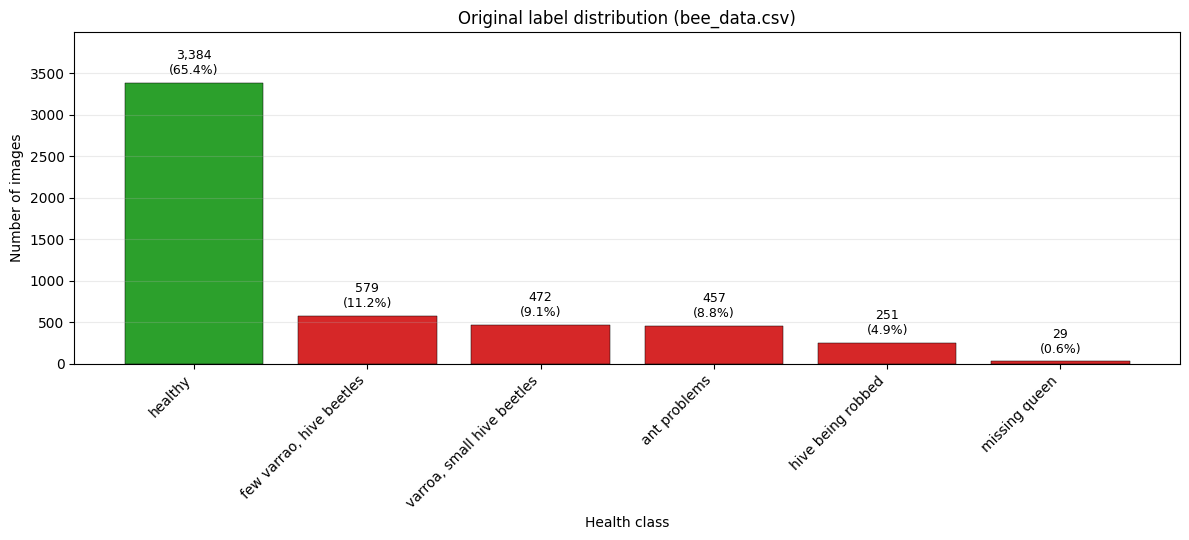

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def resolve_data_path(*relative_candidates):
    """Return the first existing path from candidate relative locations."""
    for rel_path in relative_candidates:
        candidate = Path(rel_path)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate dataset file. Checked: "
        + ", ".join(str(Path(p)) for p in relative_candidates)
    )


raw_csv_path = resolve_data_path(
    "data/raw/bee_data.csv",
    "../data/raw/bee_data.csv",
)

raw_df = pd.read_csv(raw_csv_path)
raw_health = raw_df["health"].astype(str).str.strip().str.lower()
raw_counts = raw_health.value_counts().sort_values(ascending=False)

raw_total = raw_counts.sum()
max_count = raw_counts.max()
label_offset = max_count * 0.02

plt.figure(figsize=(12, 5.5))
bar_colors = ["#2ca02c" if cls == "healthy" else "#d62728" for cls in raw_counts.index]
bars = plt.bar(raw_counts.index, raw_counts.values, color=bar_colors, edgecolor="black", linewidth=0.35)

for bar, count in zip(bars, raw_counts.values):
    pct = (count / raw_total) * 100 if raw_total else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + label_offset,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.title("Original label distribution (bee_data.csv)")
plt.ylabel("Number of images")
plt.xlabel("Health class")
plt.ylim(0, max_count * 1.18)
plt.grid(axis="y", alpha=0.25)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

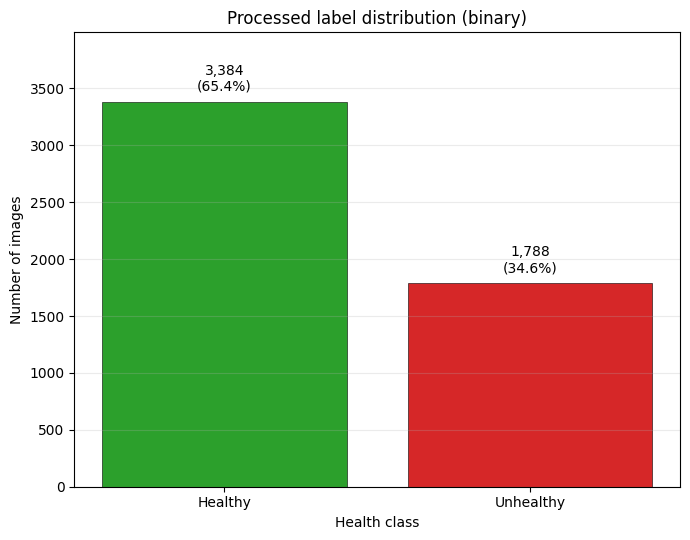

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


def resolve_data_path(*relative_candidates):
    """Return the first existing path from candidate relative locations."""
    for rel_path in relative_candidates:
        candidate = Path(rel_path)
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "Could not locate dataset file. Checked: "
        + ", ".join(str(Path(p)) for p in relative_candidates)
    )


processed_csv_path = resolve_data_path(
    "data/processed/processed_bee_data_20260330_151740.csv",
    "../data/processed/processed_bee_data_20260330_151740.csv",
)

processed_df = pd.read_csv(processed_csv_path, sep=";")

binary_counts = (
    processed_df["health"]
    .astype(str)
    .str.strip()
    .str.lower()
    .value_counts()
    .reindex(["healthy", "unhealthy"])
    .fillna(0)
    .astype(int)
)

binary_total = binary_counts.sum()
max_count = binary_counts.max()
label_offset = max_count * 0.02

plt.figure(figsize=(7, 5.5))
binary_labels = [label.title() for label in binary_counts.index]
binary_colors = ["#2ca02c", "#d62728"]
bars = plt.bar(binary_labels, binary_counts.values, color=binary_colors, edgecolor="black", linewidth=0.4)

for bar, count in zip(bars, binary_counts.values):
    pct = (count / binary_total) * 100 if binary_total else 0
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        count + label_offset,
        f"{count:,}\n({pct:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=10,
    )

plt.title("Processed label distribution (binary)")
plt.ylabel("Number of images")
plt.xlabel("Health class")
plt.ylim(0, max_count * 1.18)
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

CNN
Summary metrics (positive class = unhealthy):
Accuracy:  0.977
Precision: 0.967
Recall:    0.967
F1-score:  0.967
ROC AUC:   0.996
Training time for model: 97.76 seconds
Prediction time for model: 0.31 seconds

Hybrid
Summary metrics (positive class = unhealthy):
Accuracy:  0.975
Precision: 0.966
Recall:    0.961
F1-score:  0.964
ROC-AUC:   0.992
Training time for model: 0.05 seconds
Prediction time for model: 0.01 seconds


Random Forest
Summary metrics (positive class = unhealthy):
Accuracy:  0.921
Precision: 0.931
Recall:    0.832
F1-score:  0.879
ROC-AUC:   0.981
Training time for model: 9.11 seconds
Prediction time for model: 0.06 seconds

SVM
Summary metrics (positive class = unhealthy):
Accuracy:  0.915
Precision: 0.909
Recall:    0.838
F1-score:  0.872
ROC-AUC:   0.969
Training time for model: 60.32 seconds
Prediction time for model: 9.84 seconds